# Logistic Regression Baseline

Trains a logistic regression model on the full model-ready dataset (`model_ready.parquet`) produced by `Joined_EDA_and_Preprocessing.ipynb`. All preprocessing (imputation, OHE, NZV cleanup) has already been applied upstream.

**Design choices:**
- **Temporal train/test split** — train on trials with `start_year < 2019`, test on `start_year ≥ 2019` to prevent leakage
- **StandardScaler on numeric columns only** — OHE binary dummies are left unscaled (scaling 0/1 dummies distorts their meaning for L2-regularized LR)
- **`class_weight='balanced'`** — compensates for the ~53% / 37% / 11% class imbalance (Completed / Terminated / Withdrawn)
- **Primary metric: macro F1** — treats all three classes equally regardless of frequency

**Label encoding:** 0 = COMPLETED, 1 = TERMINATED, 2 = WITHDRAWN

In [5]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

PARQUET = 'model_ready.parquet'
LABEL_NAMES = {0: 'COMPLETED', 1: 'TERMINATED', 2: 'WITHDRAWN'}
SPLIT_YEAR = 2019

df = pl.read_parquet(PARQUET)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(df['label'].value_counts().sort('label'))

Loaded: 53,628 rows × 150 columns
shape: (3, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ 0     ┆ 28219 │
│ 1     ┆ 19694 │
│ 2     ┆ 5715  │
└───────┴───────┘


## 1. Feature Columns

Separate the continuous numeric features (to be scaled) from the binary OHE dummies (left as-is). `overall_status` and `start_year` are excluded from the feature matrix — used only for splitting and evaluation.

In [6]:
NON_FEATURE = {'label', 'overall_status', 'start_year'}

NUM_COLS = [
    'log_enrollment', 'num_primary_outcomes', 'num_secondary_outcomes',
    'num_conditions', 'num_drugs', 'num_sites', 'num_collaborators',
    'min_age_years', 'max_age_years', 'age_range_years',
    'trial_duration_days', 'approval_year', 'years_since_approval',
]
# Only keep numeric or binary (UInt8/Int8/Boolean) columns — guards against any stray strings
BIN_COLS = [
    c for c in df.columns
    if c not in NON_FEATURE
    and c not in NUM_COLS
    and df[c].dtype in (pl.UInt8, pl.Int8, pl.Boolean)
]

print(f'Numeric features  : {len(NUM_COLS)}')
print(f'Binary OHE dummies: {len(BIN_COLS)}')
print(f'Total features    : {len(NUM_COLS) + len(BIN_COLS)}')

Numeric features  : 13
Binary OHE dummies: 134
Total features    : 147


## 2. Temporal Train/Test Split

Trials with `start_year < 2019` → train; `start_year ≥ 2019` → test. This simulates real deployment: predict outcomes for future trials using only past data.

In [7]:
train = df.filter(pl.col('start_year') < SPLIT_YEAR)
test  = df.filter(pl.col('start_year') >= SPLIT_YEAR)

print(f'Train: {len(train):,} rows (start_year < {SPLIT_YEAR})')
print(f'Test:  {len(test):,}  rows (start_year ≥ {SPLIT_YEAR})')
print()
print('Train label distribution:')
print(train['label'].value_counts().sort('label'))
print()
print('Test label distribution:')
print(test['label'].value_counts().sort('label'))

Train: 40,209 rows (start_year < 2019)
Test:  13,419  rows (start_year ≥ 2019)

Train label distribution:
shape: (3, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ 0     ┆ 22075 │
│ 1     ┆ 14773 │
│ 2     ┆ 3361  │
└───────┴───────┘

Test label distribution:
shape: (3, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ 0     ┆ 6144  │
│ 1     ┆ 4921  │
│ 2     ┆ 2354  │
└───────┴───────┘


## 3. Build Feature Matrices & Scale

`StandardScaler` is fit on the training numeric columns only, then applied to both train and test. Binary OHE columns are concatenated unscaled — rescaling 0/1 indicators would shrink them to near-zero and inflate their apparent magnitude relative to continuous features.

In [8]:
X_train_num = train.select(NUM_COLS).to_numpy().astype(np.float64)
X_test_num  = test.select(NUM_COLS).to_numpy().astype(np.float64)

X_train_bin = train.select(BIN_COLS).to_numpy().astype(np.float64)
X_test_bin  = test.select(BIN_COLS).to_numpy().astype(np.float64)

# Fit scaler on train only — no test leakage
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled  = scaler.transform(X_test_num)

X_train = np.hstack([X_train_num_scaled, X_train_bin])
X_test  = np.hstack([X_test_num_scaled,  X_test_bin])

y_train = train['label'].to_numpy()
y_test  = test['label'].to_numpy()

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Feature scale check — numeric col 0 (log_enrollment) mean≈{X_train_num_scaled[:,0].mean():.3f}, std≈{X_train_num_scaled[:,0].std():.3f}')

X_train: (40209, 147)
X_test:  (13419, 147)
Feature scale check — numeric col 0 (log_enrollment) mean≈-0.000, std≈1.000


## 4. Train & Evaluate

`solver='saga'` handles large sparse feature matrices efficiently. `max_iter=3000` ensures convergence on the 147-feature scaled matrix. `class_weight='balanced'` upweights the minority WITHDRAWN class.

In [12]:
model = LogisticRegression(
    class_weight='balanced',
    solver='saga',
    max_iter=3000,
    random_state=42,
)
model.fit(X_train, y_train)
print('Training complete.')

y_pred = model.predict(X_test)

target_names = [LABEL_NAMES[i] for i in sorted(LABEL_NAMES)]
print()
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f'Macro F1: {macro_f1:.4f}')

Training complete.

              precision    recall  f1-score   support

   COMPLETED      0.831     0.682     0.749      6144
  TERMINATED      0.664     0.779     0.717      4921
   WITHDRAWN      0.904     1.000     0.949      2354

    accuracy                          0.773     13419
   macro avg      0.800     0.820     0.805     13419
weighted avg      0.783     0.773     0.773     13419

Macro F1: 0.8052


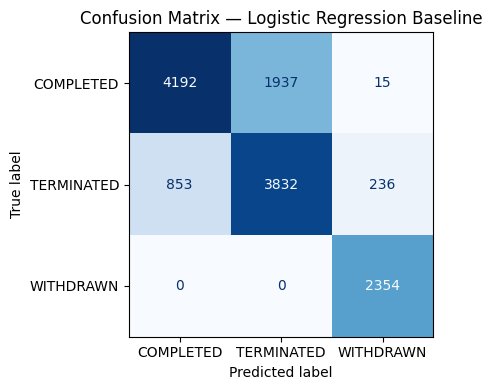

In [13]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression Baseline')
plt.tight_layout()
plt.show()

## 5. Top Predictive Features

Logistic regression coefficients (one row per class, one column per feature). For each class, show the 15 features with the largest absolute coefficient — these are the strongest linear predictors of that outcome.

/var/folders/d5/3zspmjf92d91t10nc68flbhc0000gn/T/ipykernel_27947/1052632891.py:14: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


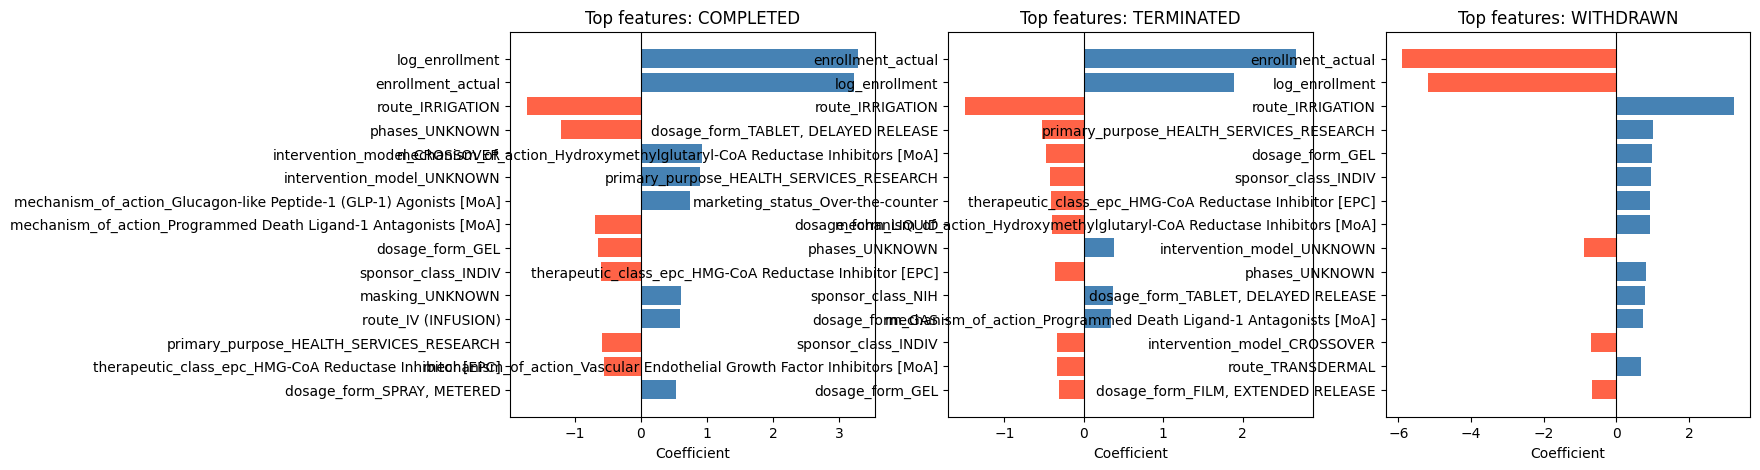

In [14]:
feature_names = NUM_COLS + BIN_COLS

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, class_idx in zip(axes, [0, 1, 2]):
    coefs = model.coef_[class_idx]
    top_idx = np.argsort(np.abs(coefs))[-15:][::-1]
    top_names = [feature_names[i] for i in top_idx]
    top_vals  = coefs[top_idx]
    colors = ['steelblue' if v > 0 else 'tomato' for v in top_vals]
    ax.barh(top_names[::-1], top_vals[::-1], color=colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Top features: {LABEL_NAMES[class_idx]}')
    ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()